========== Cambio de monedas ==========
Denominaciones disponibles: [1, 2, 5, 10, 20, 50]
Denominaciones ordenadas: [50, 20, 10, 5, 2, 1]
Monto a devolver: 380
Cambio entregado: [50, 50, 50, 50, 50, 50, 50, 20, 10]
Cantidad de monedas usadas: 9


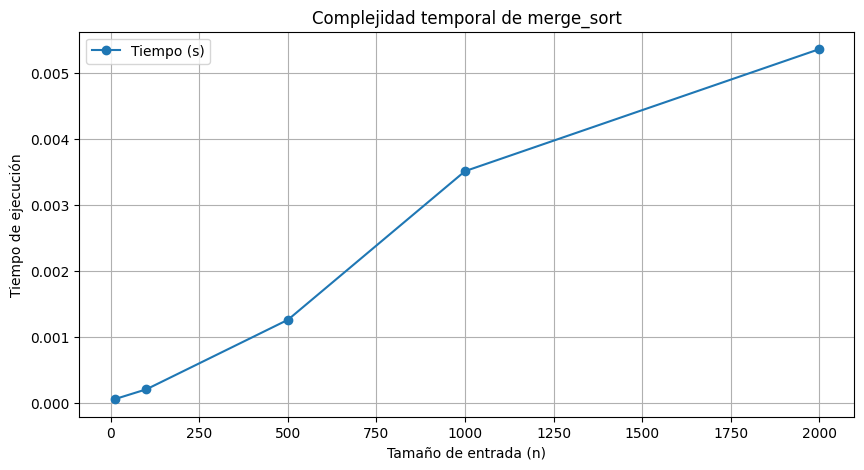

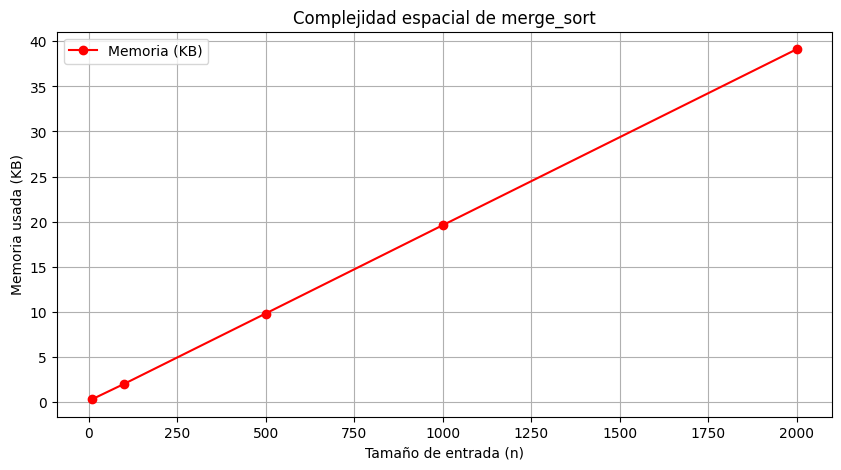

In [ ]:
import time
import tracemalloc
import matplotlib.pyplot as plt

def merge_sort(st):     # O(n log n)    S(n)
    if len(st) <= 1:
        return st
    mid = len(st) // 2

    izquierda = merge_sort(st[:mid])
    derecha = merge_sort(st[mid:])

    return merge(izquierda, derecha)

def merge(izq, der):
    resultado = []
    i = j = 0

    while i < len(izq) and j < len(der):
        if izq[i] > der[j]:
            resultado.append(izq[i])
            i += 1
        else:
            resultado.append(der[j])
            j += 1

    resultado.extend(izq[i:])
    resultado.extend(der[j:])
    
    return resultado

def cambio_recursivo(monto, monedas, indice):   # O(n)  S(n)
    if monto == 0:
        return []
    if indice >= len(monedas):
        return []
    moneda_actual = monedas[indice]
    if moneda_actual <= monto:
        return [moneda_actual] + cambio_recursivo(monto - moneda_actual, monedas, indice)
    else:
        return cambio_recursivo(monto, monedas, indice + 1)

def analizar_complejidad():
    tamanos = [10, 100, 500, 1000, 2000]
    tiempos = []
    memorias = []

    for n in tamanos:
        datos = list(range(n, 0, -1)) 

        # medir tiempo
        inicio = time.time()
        merge_sort(datos)
        fin = time.time()
        tiempos.append(fin - inicio)

        # medir memoria
        tracemalloc.start()
        merge_sort(datos)
        memoria_actual, memoria_pico = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        memorias.append(memoria_pico / 1024)

    # Graficar tiempo
    plt.figure(figsize=(10,5))
    plt.plot(tamanos, tiempos, marker='o', label="Tiempo (s)")
    plt.xlabel("Tamaño de entrada (n)")
    plt.ylabel("Tiempo de ejecución")
    plt.title("Complejidad temporal de merge_sort")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Graficar memoria
    plt.figure(figsize=(10,5))
    plt.plot(tamanos, memorias, marker='o', color="red", label="Memoria (KB)")
    plt.xlabel("Tamaño de entrada (n)")
    plt.ylabel("Memoria usada (KB)")
    plt.title("Complejidad espacial de merge_sort")
    plt.legend()
    plt.grid(True)
    plt.show()

monedas = [1, 2, 5, 10, 20, 50]

subtotal = int(input("Ingresa el total a pagar: "))
dinero = int(input("Ingresa el dinero para pagar tu total: "))

print("="*10, "Cambio de monedas", "="*10)
print(f"Denominaciones disponibles: {monedas}")
print(f"Denominaciones ordenadas: {merge_sort(monedas)}")
monto = dinero - subtotal
print(f"Monto a devolver: {monto}")
cambio = cambio_recursivo(monto, merge_sort(monedas), 0)
print(f"Cambio entregado: {cambio}")
print(f"Cantidad de monedas usadas: {len(cambio)}")

# Ejecutar análisis
analizar_complejidad()
